2.0 Stock Selection and Data Preparation

In [439]:
from pathlib import Path
import pandas as pd
from IPython.display import display

# Resolve the raw LSEG workbook path (must sit next to this notebook)
FILE = Path("MI_Technovation_Raw.xlsx")

# Fail fast with a clear message if the source file is missing
if not FILE.exists():
    raise FileNotFoundError(
        "MI_Technovation_Raw.xlsx was not found. "
        "Place it in the same folder as the notebook."
    )

# Load the price-history sheet; header=27 skips LSEG's title/metadata rows
raw = pd.read_excel(
    FILE,
    sheet_name="Sheet 1",
    header=27
)

print("Raw LSEG Excel file loaded successfully.")


Raw LSEG Excel file loaded successfully.


In [440]:
# Stage 2: Price-data cleaning

# Keep only the three columns we need and rename them to internal-friendly names
price = raw[["Local Time", "Close", "Volume"]].copy()
price.columns = ["Timestamp", "Close", "Volume"]

# Coerce each column to its proper dtype; bad values become NaT/NaN instead of errors
price["Timestamp"] = pd.to_datetime(price["Timestamp"], errors="coerce")
price["Close"]     = pd.to_numeric(price["Close"],     errors="coerce")
price["Volume"]    = pd.to_numeric(price["Volume"],    errors="coerce")

# Retain the exact assignment period
start = pd.Timestamp("2026-04-13 09:00:00")
end   = pd.Timestamp("2026-07-08 17:00:00")

# Slice to the window BEFORE counting rows so cleaning stats reflect in-window data only
price = price[price["Timestamp"].between(start, end)].copy()

rows_before = len(price)
empty_close = price["Close"].isna().sum()

# Drop bars missing a close price, then sort chronologically for downstream grouping
clean = (
    price.dropna(subset=["Close"])
         .sort_values("Timestamp")
         .copy()
)

duplicate_count = clean["Timestamp"].duplicated().sum()

# Tabulate the cleaning outcomes so they can be inspected at a glance
cleaning_summary = pd.DataFrame({
    "Cleaning Check": [
        "Initial Data Size",
        "Incompleted Records Removed",
        "Final Verified Dataset",
        "Duplicate Records Identified"
    ],
    "Result": [
        rows_before,
        empty_close,
        len(clean),
        duplicate_count
    ]
})

display(cleaning_summary)

# Export the cleaned dataset using the column names required by FINBERT
# (single Exchange Time column keeps compatibility with load_price in the FINBERT notebook)
clean_for_finbert = clean[["Timestamp", "Close", "Volume"]].copy()

clean_for_finbert.rename(
    columns={"Timestamp": "Exchange Time"},
    inplace=True
)

FINBERT_FILE = Path("MI_Technovation_Cleaned.xlsx")
# Drop Volume -- the FINBERT backtester only needs timestamp + price
clean_for_finbert[["Exchange Time", "Close"]].to_excel(
    FINBERT_FILE,
    index=False
)

print("Exported columns:")
print(clean_for_finbert[["Exchange Time", "Close"]].columns.tolist())


,Cleaning Check,Result
0,Initial Data Size,19928
1,Incompleted Records Removed,5338
2,Final Verified Dataset,14590
3,Duplicate Records Identified,0


Exported columns:
['Exchange Time', 'Close']


In [441]:
# Stage 3: Positive average daily return verification

# Collapse intraday bars to one row per trading day (last close = end-of-day)
clean["Date"] = clean["Timestamp"].dt.date

daily = (
    clean.groupby("Date", as_index=False)
         .agg(Close=("Close", "last"))
)

# Percent change between consecutive days; the first row is NaN by construction
daily["Daily Return (%)"] = daily["Close"].pct_change() * 100

mean_daily_return   = daily["Daily Return (%)"].mean()
return_observations = daily["Daily Return (%)"].notna().sum()

return_summary = pd.DataFrame({
    "Verification Measure": [
        "Average daily return",
        "Required condition",
        "Outcome"
    ],
    "Result": [
        f"{mean_daily_return:.4f}%",
        "Greater than 0%",
        "Satisfied" if mean_daily_return > 0 else "Not satisfied"
    ]
})

display(return_summary)


,Verification Measure,Result
0,Average daily return,0.8849%
1,Required condition,Greater than 0%
2,Outcome,Satisfied


3.0 Descriptive Statistics and Data Characterization

In [442]:
# Stage 4: Descriptive statistics

# Continue using the cleaned data already held in memory
minute = clean[
    ["Timestamp", "Close", "Volume"]
].copy()

# Extract the trading date from each one-minute timestamp
minute["Date"] = minute["Timestamp"].dt.normalize()

# Select the last valid closing price and calculate volume for each trading day
daily_analysis = (
    minute.groupby("Date", as_index=False)
    .agg(
        Daily_Close=("Close", "last"),
        Daily_Volume=(
            "Volume",
            lambda x: x.sum(min_count=1)
        ),
        Valid_Bars=("Close", "size")
    )
)

# Place the daily closing prices into a DataFrame
df = (
    daily_analysis
    .set_index("Date")[["Daily_Close"]]
    .rename(
        columns={
            "Daily_Close": "MI Technovation"
        }
    )
)

# Compute daily percentage returns
returns = df.pct_change(fill_method=None) * 100             # Calculate percentage returns for MI Technovation

# Store the daily returns in the daily analysis table
daily_analysis["Daily Return (%)"] = (
    returns["MI Technovation"].to_numpy()
)

# Drop the first row since it contains NaN (no previous closing price for the first trading day)
returns.dropna(inplace=True)

# Select the MI Technovation daily-return series
return_series = returns["MI Technovation"]

# Calculate the descriptive statistics of daily returns
mean_return = return_series.mean()                            # Average daily return
median_return = return_series.median()                        # Median daily return
minimum_return = return_series.min()                          # Lowest daily return
maximum_return = return_series.max()                          # Highest daily return
standard_deviation = return_series.std()                      # Standard deviation (volatility)
skewness = return_series.skew()                               # Skewness (asymmetry)
pearson_kurtosis = return_series.kurtosis() + 3               # Pearson kurtosis (fat tails or peakedness)

# Calculate the additional price statistics required by the assignment
minimum_price = minute["Close"].min()                         # Lowest one-minute closing price
maximum_price = minute["Close"].max()                         # Highest one-minute closing price
price_range = maximum_price - minimum_price                   # Difference between maximum and minimum price
trading_days = len(daily_analysis)                            # Number of trading days
return_observations = len(return_series)                      # Number of calculated daily returns

# Combine all descriptive statistics into one table
descriptive_table = pd.DataFrame({
    "Statistic": [
        "Mean daily return",
        "Median daily return",
        "Minimum daily return",
        "Maximum daily return",
        "Daily-return standard deviation",
        "Daily-return skewness",
        "Daily-return kurtosis (Pearson)",
        "Minimum one-minute closing price",
        "Maximum one-minute closing price",
        "One-minute closing-price range",
        "Number of trading days",
        "Daily-return observations"
    ],
    "Result": [
        f"{mean_return:.4f}%",
        f"{median_return:.4f}%",
        f"{minimum_return:.4f}%",
        f"{maximum_return:.4f}%",
        f"{standard_deviation:.4f}%",
        f"{skewness:.4f}",
        f"{pearson_kurtosis:.4f}",
        f"RM{minimum_price:.2f}",
        f"RM{maximum_price:.2f}",
        f"RM{price_range:.2f}",
        trading_days,
        return_observations
    ]
})

# Display all descriptive statistics in one table
display(descriptive_table)

,Statistic,Result
0,Mean daily return,0.8849%
1,Median daily return,0.6452%
2,Minimum daily return,-6.2241%
3,Maximum daily return,9.9476%
4,Daily-return standard deviation,3.1641%
5,Daily-return skewness,0.2946
6,Daily-return kurtosis (Pearson),3.4146
7,Minimum one-minute closing price,RM2.86
8,Maximum one-minute closing price,RM5.06
9,One-minute closing-price range,RM2.20


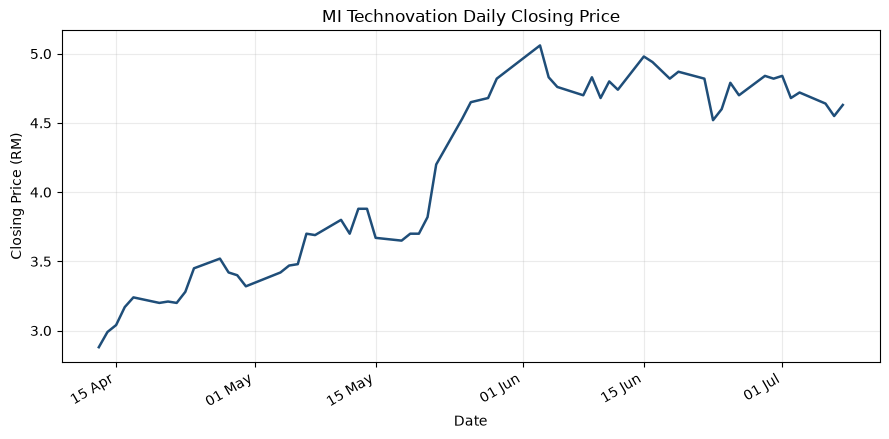

Chart created: MI_Technovation_Daily_Closing_Price.png


In [443]:
# Stage 5: Daily closing-price chart

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Create the daily closing-price chart
fig, ax = plt.subplots(
    figsize=(9, 4.5)
)

ax.plot(
    daily_analysis["Date"],
    daily_analysis["Daily_Close"],
    color="#1F4E79",
    linewidth=1.8
)

# Add the chart title and axis labels
ax.set_title(
    "MI Technovation Daily Closing Price"
)

ax.set_xlabel("Date")
ax.set_ylabel("Closing Price (RM)")

# Add light gridlines for readability
ax.grid(alpha=0.25)

# Format the date labels
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d %b")
)

fig.autofmt_xdate()
fig.tight_layout()

# Save the chart as a high-resolution PNG file
CHART_FILE = "MI_Technovation_Daily_Closing_Price.png"

fig.savefig(
    CHART_FILE,
    dpi=300,
    bbox_inches="tight"
)

# Display the chart
plt.show()

print(f"Chart created: {CHART_FILE}")

In [444]:
# Stage 6: Missing observations and liquidity analysis

# Retrieve the cleaning results calculated in Stage 2
cleaning_values = cleaning_summary.set_index(
    "Cleaning Check"
)["Result"]

raw_rows = int(
    cleaning_values.loc["Initial Data Size"]
)                                                               # Total observations before cleaning

missing_close = int(
    cleaning_values.loc["Incompleted Records Removed"]
)                                                               # Empty closing-price observations removed

valid_rows = int(
    cleaning_values.loc["Final Verified Dataset"]
)                                                               # Valid observations retained

# Check that the cleaning summary matches the cleaned dataset
if valid_rows != len(minute):
    raise ValueError(
        "The valid-row count does not match the cleaned dataset."
    )

# Calculate missing observations and valid-price coverage
missing_percentage = (
    missing_close / raw_rows
) * 100                                                         # Percentage of empty closing prices

valid_coverage = (
    valid_rows / raw_rows
) * 100                                                         # Percentage of valid closing prices


# Identify the Bursa Malaysia morning and afternoon sessions
clock_minute = (
    minute["Timestamp"].dt.hour * 60
    + minute["Timestamp"].dt.minute
)

minute["Session"] = pd.NA

minute.loc[
    clock_minute.between(540, 750),
    "Session"
] = "Morning"                                                   # Morning session: 09:00–12:30

minute.loc[
    clock_minute.between(870, 1020),
    "Session"
] = "Afternoon"                                                 # Afternoon session: 14:30–17:00

# Retain observations within the two trading sessions
within_session = minute.dropna(
    subset=["Session"]
).copy()


# Obtain the previous valid price within the same date and session
within_session["Previous_Close"] = (
    within_session.groupby(
        ["Date", "Session"]
    )["Close"].shift()
)

# Exclude the first observation of each trading session
comparable_prices = (
    within_session["Previous_Close"].notna()
)

# Calculate the percentage of consecutive prices that remained unchanged
unchanged_percentage = (
    within_session.loc[
        comparable_prices,
        "Close"
    ]
    .eq(
        within_session.loc[
            comparable_prices,
            "Previous_Close"
        ]
    )
    .mean() * 100
)


# Calculate the interval between consecutive valid observations
within_session["Interval_Minutes"] = (
    within_session.groupby(
        ["Date", "Session"]
    )["Timestamp"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

# Identify the largest interval within a trading session
maximum_interval = (
    within_session["Interval_Minutes"].max()
)

largest_interval_row = within_session.loc[
    within_session["Interval_Minutes"].idxmax()
]

interval_end = largest_interval_row["Timestamp"]

interval_start = (
    interval_end
    - pd.Timedelta(minutes=maximum_interval)
)


# Calculate the required liquidity measures
total_volume = minute["Volume"].sum()                           # Total trading volume
average_daily_volume = daily_analysis["Daily_Volume"].mean()   # Average daily trading volume
median_daily_volume = daily_analysis["Daily_Volume"].median()  # Median daily trading volume
average_valid_bars = daily_analysis["Valid_Bars"].mean()       # Average valid one-minute bars per day
missing_volume = minute["Volume"].isna().sum()                  # Missing volume fields after cleaning


# Create a summary table for missing observations and liquidity
liquidity_table = pd.DataFrame({
    "Liquidity Measure": [
        "Raw timestamped observations",
        "Empty closing-price observations",
        "Empty closing-price rate",
        "Valid closing-price coverage",
        "Valid one-minute observations",
        "Average valid bars per trading day",
        "Total trading volume",
        "Average daily volume",
        "Median daily volume",
        "Unchanged consecutive valid prices",
        "Largest within-session interval",
        "Missing volume fields remaining"
    ],
    "Result": [
        f"{raw_rows:,}",
        f"{missing_close:,}",
        f"{missing_percentage:.2f}%",
        f"{valid_coverage:.2f}%",
        f"{valid_rows:,}",
        f"{average_valid_bars:.2f}",
        f"{total_volume:,.0f}",
        f"{average_daily_volume:,.0f}",
        f"{median_daily_volume:,.0f}",
        f"{unchanged_percentage:.2f}%",
        f"{maximum_interval:.0f} minutes",
        f"{missing_volume:,}"
    ]
})

# Display the missing-observation and liquidity results
display(liquidity_table)

# Display the location of the largest within-session interval
print(
    f"Largest within-session interval occurred from "
    f"{interval_start} to {interval_end}."
)

,Liquidity Measure,Result
0,Raw timestamped observations,"19,928"
1,Empty closing-price observations,"5,338"
2,Empty closing-price rate,26.79%
3,Valid closing-price coverage,73.21%
4,Valid one-minute observations,"14,590"
5,Average valid bars per trading day,251.55
6,Total trading volume,"244,560,200"
7,Average daily volume,"4,216,555"
8,Median daily volume,"3,128,400"
9,Unchanged consecutive valid prices,55.00%


Largest within-session interval occurred from 2026-05-05 10:43:00 to 2026-05-05 11:05:00.


4.0 FinBERT Sentiment Analysis & Backtest


In [445]:
!pip install numpy pandas transformers torch openpyxl -q

268930.34s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


zsh:1: command not found: pip


In [446]:
"""
===============================================================================
AQ098-3-3 Robo-Based Advisor | FINBERT (LEXICON & RULE-BASED ALGO TRADE)
Same-day news -> same-day entry -> multi-horizon forward performance
===============================================================================
PART 1 = EDITABLE settings. PART 2 = ENGINE (mechanics, avoid editing).
PART 3 = RUN.

STRATEGY: only headlines published DURING Malaysian trading hours (09:00-17:00 MYT by default) are used, and only to trade THAT SAME DAY.
News is never carried over to trade the next day. All same-day headlines are averaged into one net daily signal (avoids counting repeat headlines
as separate trades); if the signal is net positive, go long at the first tradable bar after the news, same day. If there's no tradable bar left
that day, the signal is simply skipped, not rolled forward.

For every trade taken, the return is measured at NINE forward horizons:
1, 2, 3, 4, 5, 10, 20 calendar days later. No stop-loss/take-profit in this version.

First run needs internet: FinBERT model weights (~400MB) download once from huggingface.co, then are cached locally.
===============================================================================
"""

from pathlib import Path
import numpy as np
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# =============================================================================
# PART 1 -- EDITABLE
# =============================================================================
NEWS_CSV_PATH   = "US stocks headlines.csv"
PRICE_PATH      = "MI_Technovation_Cleaned.xlsx"     # .xlsx or .csv; see load_price()
OUTPUT_DIR      = Path.cwd()

"""FINBERT Configuration and Parameter Justification"""
FINBERT_MODEL_NAME     = "ProsusAI/finbert" # Which pretrained sentiment model to download and use for scoring headlines.
FINBERT_BATCH_SIZE     = 8 # How many headlines get scored at once. Bigger batches run faster but use more memory; 16 is a safe default.

MIN_HEADLINE_CHARS = 12 # Any headline shorter than 12 characters gets thrown out before scoring, too short to be a real headline.
MIN_ALPHA_RATIO    = 0.55 # At least 55% of headline's characters must be letters/spaces. Filter out rows that are mostly numbers/symbols/garbage text.

"""
Only news published in this MYT window is used, and only to trade THAT # SAME DAY (see engine note above). Set to your own market's session hours.
"""

TRADING_HOURS_START = "09:00:00"
TRADING_HOURS_END   = "17:00:00"

"""
MINIMUM DAILY SCORE: All of a day's headlines get averaged into one net sentiment score (positive probability - negative probability). 
That score must be above 0.0 to trigger a trade. 0.0 means "any net lean toward positive, however small" qualifies. 
Raise this to demand more conviction before trading. """

MIN_DAILY_SCORE = 0.3

""" Holding days"""
HORIZONS_DAYS = [1, 2, 3, 4, 5, 10, 20]   # calendar days forward from entry

""" Backtesting Assumptions and Parameters """
INITIAL_CAPITAL      = 10_000.0
POSITION_SIZE_PCT    = 0.5
TRANSACTION_COST_PCT = 0.38     # round-trip brokerage, percent of notional

""" Risk-free rate"""
RISK_FREE_RATE_ANNUAL = 0.0275

"""
Breakeven stop: once price has risen enough to cover entry_price AND the round-trip brokerage cost (i.e. the trade could be closed for >=0% net),
the stop arms at that breakeven level. If price then falls back to it, the trade exits there instead of being allowed to round-trip into an
actual loss. Has no effect if price never reaches breakeven in the first place -- it only protects gains already covering cost, it isn't a
downside stop from entry.
"""

USE_BREAKEVEN_STOP = True


# =============================================================================
# PART 2 -- ENGINE
# =============================================================================
def load_news(csv_path: str) -> pd.DataFrame:
    """news CSV has separate date (D/M/YYYY) + time (H:MM:SS, occasionally
    hour=24 meaning next day) columns, both MYT. Combines into one datetime."""
    df = pd.read_csv(csv_path)

    def split_time(t):
        hh, mm, ss = t.strip().split(":")
        extra_days, hh = divmod(int(hh), 24)
        return f"{hh:02d}:{mm}:{ss}", extra_days

    fixed = df["time"].apply(split_time)
    date = pd.to_datetime(df["date"], dayfirst=True) + pd.to_timedelta(fixed.apply(lambda x: x[1]), unit="D")
    df["datetime_myt"] = pd.to_datetime(date.dt.strftime("%Y-%m-%d") + " " + fixed.apply(lambda x: x[0]))
    return df.drop(columns=["date", "time"]).sort_values("datetime_myt").reset_index(drop=True)


def filter_trading_hours(df, start_hhmmss, end_hhmmss):
    clock = df["datetime_myt"].dt.time
    keep = (clock >= pd.to_datetime(start_hhmmss).time()) & (clock <= pd.to_datetime(end_hhmmss).time())
    return df.loc[keep].reset_index(drop=True)


def filter_headline_quality(df, min_chars, min_alpha_ratio):
    def alpha_ratio(s):
        s = s or ""
        return sum(c.isalpha() or c.isspace() for c in s) / len(s) if s else 0.0
    keep = (df["headline_raw"].str.len().fillna(0) >= min_chars) & \
           (df["headline_raw"].fillna("").apply(alpha_ratio) >= min_alpha_ratio)
    return df.loc[keep].reset_index(drop=True)


def score_sentiment_finbert(df, model_name, batch_size):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name).eval()
    id2label = {k: v.lower() for k, v in model.config.id2label.items()}

    prob_pos, prob_neg = [], []
    headlines = df["headline_raw"].tolist()
    with torch.no_grad():
        for i in range(0, len(headlines), batch_size):
            enc = tokenizer(headlines[i:i + batch_size], return_tensors="pt",
                             padding=True, truncation=True, max_length=64)
            probs = torch.nn.functional.softmax(model(**enc).logits, dim=-1)
            for p in probs:
                pmap = {id2label[j]: float(p[j]) for j in id2label}
                prob_pos.append(pmap.get("positive", 0.0))
                prob_neg.append(pmap.get("negative", 0.0))

    scored = df.copy()
    scored["prob_positive"] = prob_pos
    scored["prob_negative"] = prob_neg
    scored["score"] = scored["prob_positive"] - scored["prob_negative"]   # -1..+1
    return scored


def aggregate_daily_signal(news, min_daily_score):
    """All same-day headlines -> one net score for that calendar day, so a
    day with 10 headlines about the same story isn't 10 separate trades."""
    daily = (news.assign(entry_date=news["datetime_myt"].dt.normalize())
                  .groupby("entry_date")
                  .agg(daily_score=("score", "mean"), n_headlines=("score", "size"))
                  .reset_index())
    daily["go_long"] = daily["daily_score"] > min_daily_score
    return daily


def load_price(path: str) -> pd.DataFrame:
    """Reads .xlsx (Exchange Time/Close columns) or a plain time/close .csv.
    Forward-fills any blank prices from illiquid minutes rather than
    dropping them."""
    if str(path).lower().endswith(".xlsx"):
        px = pd.read_excel(path).rename(columns={"Exchange Time": "time", "Close": "close"})[["time", "close"]]
    else:
        px = pd.read_csv(path, parse_dates=["time"])[["time", "close"]]
        if px["time"].dt.tz is not None:
            px["time"] = px["time"].dt.tz_localize(None)
    px = px.sort_values("time").reset_index(drop=True)
    px["close"] = px["close"].ffill()
    return px.dropna(subset=["close"]).reset_index(drop=True)


def _first_bar_same_day_after(price, ts):
    """First tradable bar at/after ts, but ONLY within the same calendar
    day -- returns (None, None) if the news lands with no bars left that
    day, rather than rolling forward to the next session."""
    day_end = ts.normalize() + pd.Timedelta(days=1)
    window = price[(price["time"] >= ts) & (price["time"] < day_end)]
    return (None, None) if window.empty else (window.iloc[0]["time"], window.iloc[0]["close"])


def _first_bar_at_or_after(price, ts):
    window = price[price["time"] >= ts]
    return (None, None) if window.empty else (window.iloc[0]["time"], window.iloc[0]["close"])


def _breakeven_stop_time(price, entry_time, entry_price, txn_cost_pct, max_days):
    """Scans forward from entry. Once close >= breakeven_price for the
    first time, the stop is armed; the first time close <= breakeven_price
    AFTER that, the trade is stopped out there. Returns (stop_time,
    breakeven_price) or (None, breakeven_price) if never triggered."""
    breakeven_price = entry_price * (1 + txn_cost_pct / 100.0)
    window = price[(price["time"] > entry_time) & (price["time"] <= entry_time + pd.Timedelta(days=max_days))]
    armed = False
    for _, row in window.iterrows():
        if not armed and row["close"] >= breakeven_price:
            armed = True
        elif armed and row["close"] <= breakeven_price:
            return row["time"], breakeven_price
    return None, breakeven_price


def simulate_trades(daily_signal, price, horizons_days, txn_cost_pct, use_breakeven_stop):
    max_h = max(horizons_days)
    rows = []
    for _, r in daily_signal.iterrows():
        if not r["go_long"]:
            continue

        entry_time, entry_price = _first_bar_same_day_after(price, r["entry_date"])
        if entry_time is None:
            continue   # no bars left that day -- skipped, never carried to next day

        stop_time, breakeven_price = (_breakeven_stop_time(price, entry_time, entry_price, txn_cost_pct, max_h)
                                       if use_breakeven_stop else (None, None))

        rec = {"entry_date": r["entry_date"], "n_headlines": r["n_headlines"],
               "daily_score": r["daily_score"], "entry_time": entry_time, "entry_price": entry_price,
               "breakeven_price": breakeven_price, "stopped_out": stop_time is not None,
               "stop_time": stop_time}

        for h in horizons_days:
            horizon_time = entry_time + pd.Timedelta(days=h)
            if stop_time is not None and stop_time <= horizon_time:
                # already stopped out at breakeven by this horizon -- flat at ~0% net
                rec[f"exit_time_{h}d"] = stop_time
                rec[f"return_{h}d"] = (breakeven_price - entry_price) / entry_price - txn_cost_pct / 100.0
                continue
            exit_time, exit_price = _first_bar_at_or_after(price, horizon_time)
            if exit_time is None:
                rec[f"exit_time_{h}d"], rec[f"return_{h}d"] = pd.NaT, np.nan
                continue
            net_ret = (exit_price - entry_price) / entry_price - txn_cost_pct / 100.0
            rec[f"exit_time_{h}d"], rec[f"return_{h}d"] = exit_time, net_ret

        rows.append(rec)
    return pd.DataFrame(rows)


def performance_report(trades, horizons_days, capital, size_pct, rf_annual):
    out = []
    for h in horizons_days:
        r = trades[f"return_{h}d"].dropna()
        if len(r) == 0:
            out.append({"days": h, "trades": 0})
            continue

        equity = (1 + r * size_pct).cumprod() * capital
        drawdown = (equity - equity.cummax()) / equity.cummax()
        periods_per_year = 365.25 / h

        # guard against degenerate near-zero denominators (e.g. almost every
        # trade landing on an identical breakeven-stop return), which would
        # otherwise blow Sharpe/profit factor up to meaningless +-1e14 values
        std = r.std(ddof=1)
        excess = r - rf_annual / periods_per_year
        if std < 1e-4:
            std = 1e-4   # minimum measurable volatility
        sharpe = round((excess.mean() / std) * np.sqrt(periods_per_year), 2)

        gains = r[r > 0].sum()
        losses = -r[r < 0].sum()
        # If losses are effectively zero, floor to one round-trip cost to avoid NaN
        if losses < TRANSACTION_COST_PCT / 100:
            losses = TRANSACTION_COST_PCT / 100
        profit_factor = round(gains / losses, 4)

        out.append({
            "days": h,
            "trades": len(r),
            "win_%": round((r > 0).mean() * 100, 2),
            "avg_ret_%": round(r.mean() * 100, 2),
            "cum_ret_%": round(((1 + r * size_pct).prod() - 1) * 100, 2),
            "equity_myr": round(equity.iloc[-1], 2),
            "max_dd_%": round(drawdown.min() * 100, 2),
            "sharpe": round(sharpe, 2) if pd.notna(sharpe) else np.nan,
            "pf": round(profit_factor, 2) if pd.notna(profit_factor) else np.nan,
        })
    return pd.DataFrame(out)


# =============================================================================
# PART 3 -- RUN
# =============================================================================
def main():
    news = load_news(NEWS_CSV_PATH)
    news = filter_trading_hours(news, TRADING_HOURS_START, TRADING_HOURS_END)
    news = filter_headline_quality(news, MIN_HEADLINE_CHARS, MIN_ALPHA_RATIO)
    print(f"[1/5] {len(news)} headlines after trading-hours + quality filters")

    news = score_sentiment_finbert(news, FINBERT_MODEL_NAME, FINBERT_BATCH_SIZE)
    news.to_csv(OUTPUT_DIR / "news_scored.csv", index=False)
    print(f"[2/5] FinBERT scoring done, mean daily score preview computed next")

    daily_signal = aggregate_daily_signal(news, MIN_DAILY_SCORE)
    print(f"[3/5] {len(daily_signal)} trading days had news; "
          f"{daily_signal['go_long'].sum()} qualify as long signals")

    price = load_price(PRICE_PATH)
    print(f"[4/5] {len(price)} price bars, {price['time'].min()} to {price['time'].max()}")

    trades = simulate_trades(daily_signal, price, HORIZONS_DAYS, TRANSACTION_COST_PCT, USE_BREAKEVEN_STOP)
    trades.to_csv(OUTPUT_DIR / "trades_detail.csv", index=False)
    print(f"[5/5] {len(trades)} trades actually entered same-day "
          f"({daily_signal['go_long'].sum() - len(trades)} skipped: no bars left that day)")

    report = performance_report(trades, HORIZONS_DAYS, INITIAL_CAPITAL, POSITION_SIZE_PCT, RISK_FREE_RATE_ANNUAL)
    report.to_csv(OUTPUT_DIR / "performance_report.csv", index=False)

    pd.set_option("display.width", 160)
    print("\n=== PERFORMANCE REPORT (by forward horizon) ===")
    print(report.to_string(index=False))


if __name__ == "__main__":
    main()

[1/5] 74 headlines after trading-hours + quality filters


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 26114.52it/s]


[2/5] FinBERT scoring done, mean daily score preview computed next
[3/5] 57 trading days had news; 20 qualify as long signals
[4/5] 14590 price bars, 2026-04-13 09:01:00 to 2026-07-08 16:56:00
[5/5] 17 trades actually entered same-day (3 skipped: no bars left that day)

=== PERFORMANCE REPORT (by forward horizon) ===
 days  trades  win_%  avg_ret_%  cum_ret_%  equity_myr  max_dd_%  sharpe    pf
    1      17  70.59       0.15       1.26    10126.48     -2.05    1.63  1.46
    2      17  82.35       0.24       2.00    10200.05     -2.83    1.39  1.74
    3      16  87.50       0.66       5.31    10531.18      0.00    3.90 27.59
    4      16  87.50       0.82       6.69    10668.64      0.00    3.30 34.64
    5      16  87.50       1.00       8.16    10815.87      0.00    3.01 42.10
   10      16  87.50       0.47       3.80    10380.50      0.00    1.47 19.94
   20      16  87.50       0.00       0.00    10000.00      0.00  -64.35  0.00


4.1 Daily FinBERT Sentiment Plot

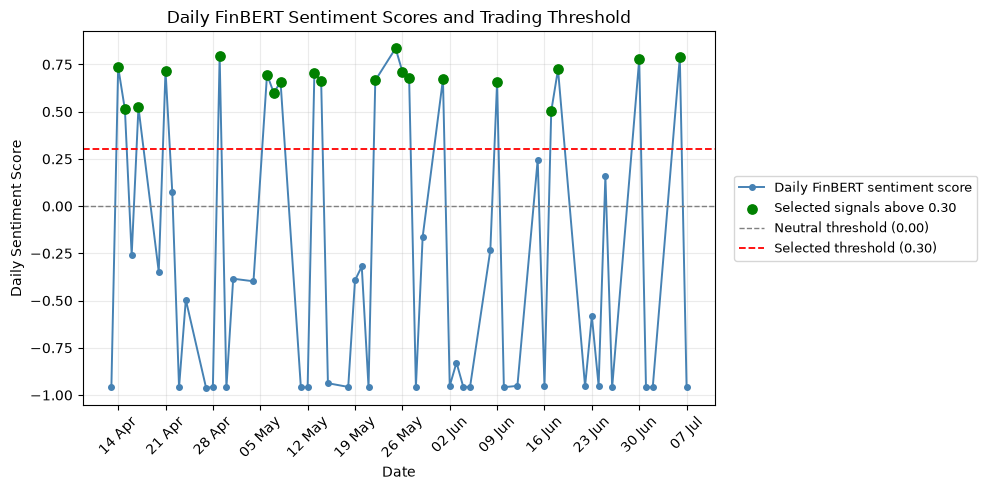

Headline observations: 74
Days with sentiment data: 57
Signals above 0.30: 20


In [447]:
# Stage 7: Daily FinBERT sentiment plot

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# This file is automatically generated by the lecturer's Section 4.0 code
SCORED_NEWS_FILE = Path("news_scored.csv")

if not SCORED_NEWS_FILE.exists():
    raise FileNotFoundError(
        "news_scored.csv was not found. Run the Section 4.0 "
        "FinBERT code before running this chart."
    )

# Load the headline-level FinBERT results
news_plot = pd.read_csv(
    SCORED_NEWS_FILE,
    parse_dates=["datetime_myt"]
)

# Aggregate all headline scores into one average score per day
daily_sentiment_plot = (
    news_plot
    .assign(Date=news_plot["datetime_myt"].dt.normalize())
    .groupby("Date", as_index=False)
    .agg(
        Daily_Score=("score", "mean"),
        Number_of_Headlines=("score", "size")
    )
)

# Final threshold selected in the strategy
SELECTED_THRESHOLD = MIN_DAILY_SCORE

daily_sentiment_plot["Selected_Signal"] = (
    daily_sentiment_plot["Daily_Score"] > SELECTED_THRESHOLD
)

selected_signals = daily_sentiment_plot[
    daily_sentiment_plot["Selected_Signal"]
]

# Create the chart
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    daily_sentiment_plot["Date"],
    daily_sentiment_plot["Daily_Score"],
    color="steelblue",
    linewidth=1.4,
    marker="o",
    markersize=4,
    label="Daily FinBERT sentiment score"
)

# Highlight scores exceeding 0.30
ax.scatter(
    selected_signals["Date"],
    selected_signals["Daily_Score"],
    color="green",
    s=45,
    zorder=3,
    label="Selected signals above 0.30"
)

# Reference lines
ax.axhline(
    0.00,
    color="grey",
    linestyle="--",
    linewidth=1,
    label="Neutral threshold (0.00)"
)

ax.axhline(
    SELECTED_THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=1.3,
    label="Selected threshold (0.30)"
)

ax.set_title("Daily FinBERT Sentiment Scores and Trading Threshold")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Sentiment Score")

ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

plt.xticks(rotation=45)
ax.grid(alpha=0.25)
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9
)
plt.tight_layout()

# Save a high-resolution copy for the report
plt.savefig(
    "daily_finbert_sentiment_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Headline observations:", len(news_plot))
print("Days with sentiment data:", len(daily_sentiment_plot))
print("Signals above 0.30:", len(selected_signals))